# Sample Inference with vLLM Server

This notebook demonstrates how to perform inference using the vLLM server that you started in Step 3 of the setup process.

## Prerequisites

Before running this notebook, ensure that:
1. You have completed Steps 1-3 in the [README.md](README.md)
2. The vLLM server is running (started via `vllm serve` command in Step 3)
3. The server is accessible at `http://localhost:8000`

## What This Notebook Does

This notebook will:
1. Load a sample geospatial image (TIFF format)
2. Send an inference request to the running vLLM server
3. Receive and visualize the segmentation mask output

Let's begin by importing the required libraries and loading our sample data.

---

In [1]:
from pathlib import Path
from tempfile import NamedTemporaryFile
from typing import Any
from urllib.parse import urlparse
import numpy as np
import rasterio
import requests
from rasterio.errors import RasterioIOError
import matplotlib.pyplot as plt
import base64
import json
import requests

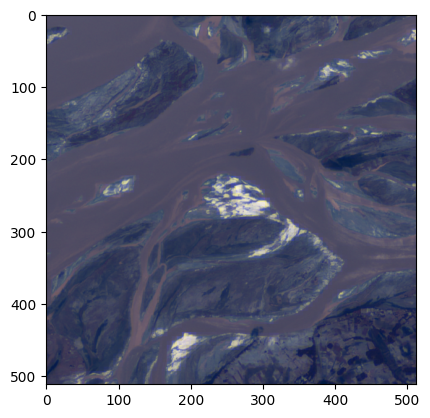

In [2]:

# Read the original image
with rasterio.open("../samples/India_900498_S2Hand.tif") as img_src:
    # Read RGB bands (assuming bands 1, 2, 3 are RGB or similar)
    #img_data = img_src.read([1, 2, 3])
    img_data = img_src.read([3, 2, 1])
    # Transpose to (height, width, channels) for matplotlib
    img_rgb = np.transpose(img_data, (1, 2, 0))
    # Normalize to 0-1 range for display
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())

plt.imshow(img_rgb)

In [ ]:
payload = {
    "data": {
        "data": "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/resolve/main/examples/India_900498_S2Hand.tif",
        "indices": [1, 2, 3, 8, 11, 12],
        "data_format": "url",
        "out_data_format": "b64_json",
        "image_format": "tiff",
    },
    "model": "1_run_model_in_vllm",
}

response = requests.post(
    "http://localhost:8000/pooling",
    headers={"Content-Type": "application/json"},
    data=json.dumps(payload),
)

if response.status_code == 200:
    result = response.json()
    mask_b64 = result["data"]["data"]
    mask_bytes = base64.b64decode(mask_b64)
    with open("mask.tiff", "wb") as f:
        f.write(mask_bytes)
    print("Segmentation mask saved as mask.tiff")
else:
    print(f"Error: Received status code {response.status_code}")
    print(f"Response: {response.text}")

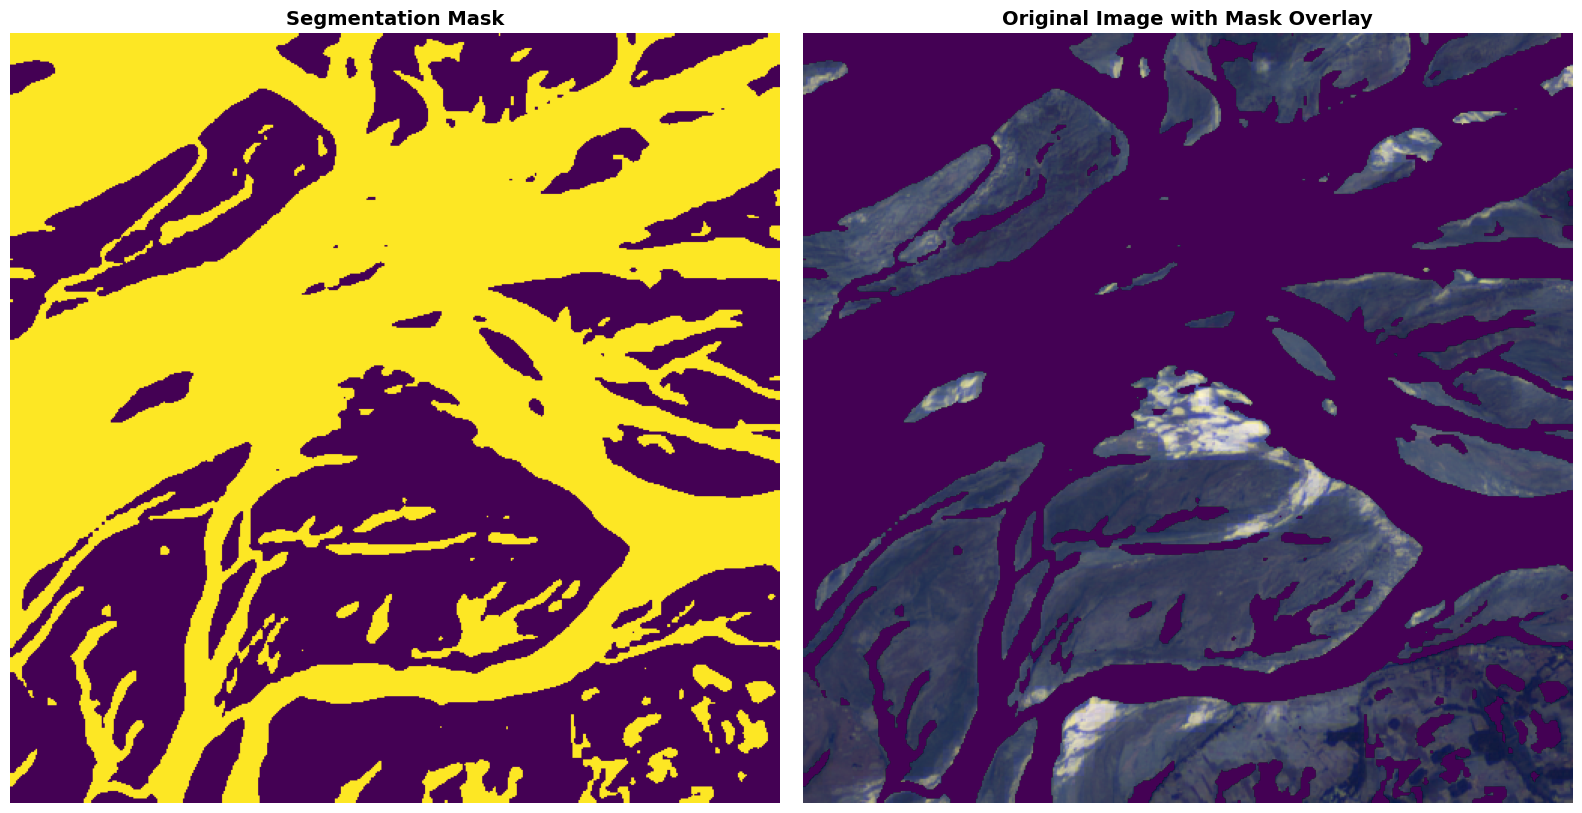

In [ ]:
# Read the mask
with rasterio.open('mask.tiff') as mask_src:
    mask = mask_src.read(1)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Show mask only
axes[0].imshow(mask, cmap='viridis')
axes[0].set_title('Segmentation Mask', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Right: Show original image with mask overlay
axes[1].imshow(img_rgb)
# Overlay mask with transparency
mask_overlay = np.ma.masked_where(mask == 0, mask)
axes[1].imshow(mask_overlay)
axes[1].set_title('Original Image with Mask Overlay', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()